Imagine This:
We’re teachers.
We gave a quiz to our class.
Some students got questions wrong. We want to help them more next time.

So, we focus more on those students next time.
We’re giving them more "weight" — more attention!

In Machine Learning:
Each data point has a weight (importance).

At first, all data points have equal weight (same importance).

After each weak model:

If a point was predicted wrong, increase its weight.
- Tell the next model: “Please try harder on this one.”

If a point was predicted right, lower its weight.
- “This one’s already easy.”

#  AdaBoost Algorithm

### 1. Start with equal weights  
- Treat all data points the same at first.  
- Every point is equally important.

---

### 2. Train a weak model (stump)  
- Use a tiny decision tree (just one rule) to make predictions.  
- It’s simple and might make mistakes.

---

### 3. Check the errors  
- Count how many points it got wrong.  
- Points with higher weights matter more.

---

### 4. Give a score to the model   
- If it did well (few mistakes), give it a high score.  
- This score shows how much we trust this model.

---

### 5. Update the weights  
- **Increase** weight for wrong predictions – so next model focuses on them.  
- **Decrease** weight for correct ones – they’re already easy.  
- Adjust so all weights add up to 1 again.

---

### 6. Repeat  
- Train another weak model using the new weights.  
- Do this several times to get better results.

---

### 7. Final prediction  
- Combine all models using their scores (weighted vote).  
- The final answer is based on the vote of all the weak models.


| Salary | Credit | Approval |
|--------|--------|----------|
| <=50K  | B      | No       |
| <=50K  | G      | Yes      |
| <=50K  | G      | Yes      |
| >50K   | B      | No       |
| >50K   | G      | Yes      |
| >50K   | N      | Yes      |
| <=50K  | N      | No       |


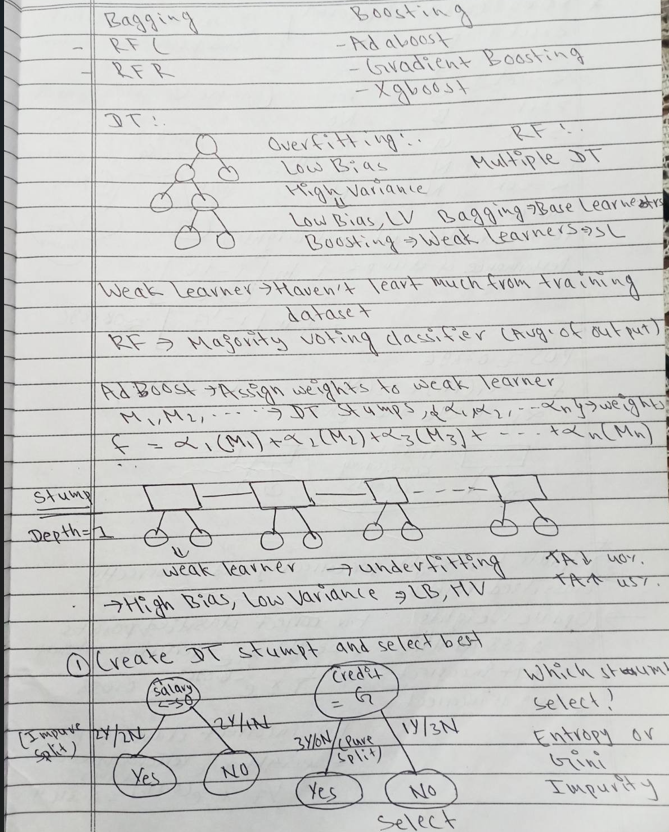

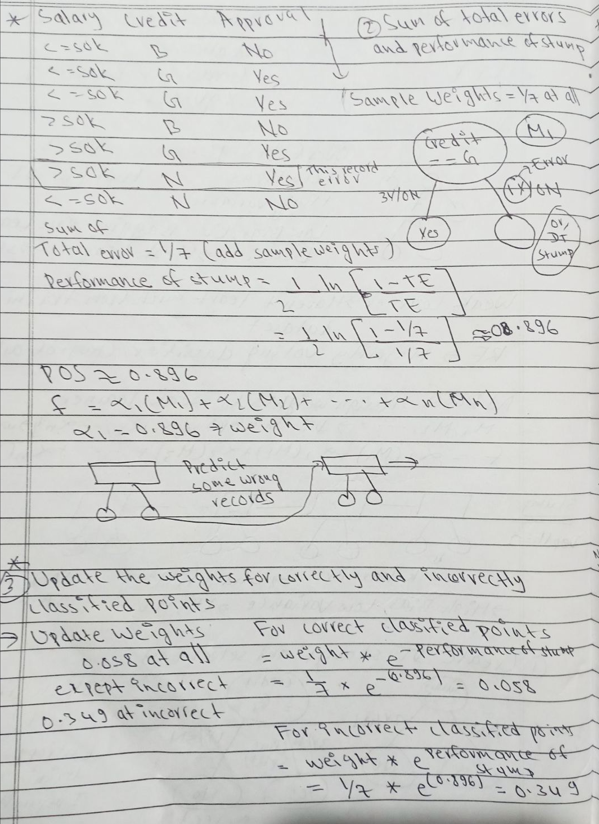

In [ ]:
0.058 * 6 + 0.349

In [ ]:
0.08 * 6 + 0.5

In [ ]:
0.058 / 0.697

In [ ]:
0.349 / 0.697

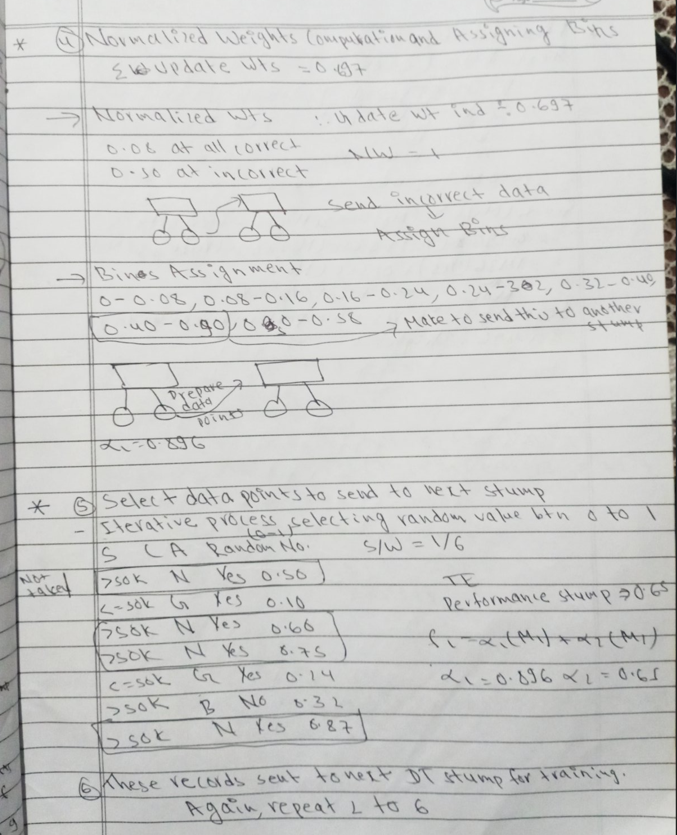

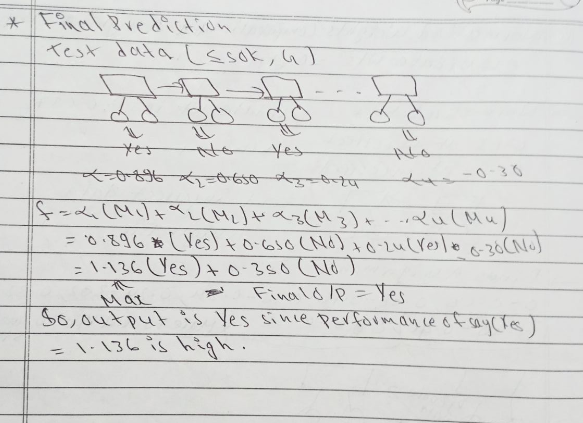

# Holiday Package Prediction

### 1) Problem Statement

"Trips & Travel.com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are five types of packages the company is offering. They are Basic, Standard, Deluxe, Super Deluxe and King, Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance oro kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

### 2) Data Collection

The dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction It consists of 20 columns and 4888 rows

In [ ]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


DATA CLEANING

- Handling Missing Values
- Handling Duplicates
- Check Data Type
- Understand the Dataset

In [ ]:
# Check missing values
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [ ]:
# Check all the categories
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [ ]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1972


In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Divorced,950
Single,916
Unmarried,682


In [ ]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Unmarried,1598
Divorced,950


In [ ]:
df['TypeofContact'].value_counts()

,count
TypeofContact,
Self Enquiry,3444
Company Invited,1419


In [ ]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1972


In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2340
Unmarried,1598
Divorced,950


In [ ]:
## Checking Missing Values

# These are the features with nan value

features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]

In [ ]:
features_with_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [ ]:
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean() * 100, 2), '% missing values')

Age 4.62 % missing values
TypeofContact 0.51 % missing values
DurationOfPitch 5.14 % missing values
NumberOfFollowups 0.92 % missing values
PreferredPropertyStar 0.53 % missing values
NumberOfTrips 2.86 % missing values
NumberOfChildrenVisiting 1.35 % missing values
MonthlyIncome 4.77 % missing values


In [ ]:
# Statistics on numerical columns(NULL COLS)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


### Imputing Null Values

1. Impute Median  for 'Age' column
2. Impute Mode for 'TypeofContact' column
3. Impute Median for 'DurationOfPitch' column
4. Impute Mode for 'NumberofFollowups' column as it is discrete feature
5. Impute Mode for 'PreferredPropertyStar' column
6. Impute Median for 'NumberOfTrips' column
7. Impute Mode for 'NumberOfChildrenVisiting' column
8. Impute Median for 'MonthlyIncome' column

In [ ]:
# Age
df.Age.fillna(df.Age.median(), inplace=True)

# TypeofContact
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

# DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

# NumberofFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

# PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

# NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

# NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

# MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

In [ ]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,0
TypeofContact,0
CityTier,0
DurationOfPitch,0
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,0


In [ ]:
df.drop('CustomerID', axis=1, inplace=True)

In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
df.duplicated().sum()

np.int64(141)

In [ ]:
df = df.drop_duplicates(keep='first')

In [ ]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

#### Feature Extraction

In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
# Create a new column TotalVisits
df['TotalVisits'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [ ]:
## Get all the numerical columns
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']
print('Number of numerical features: ', len(numerical_features))

Number of numerical features:  12


In [ ]:
# Get all the categorical columns
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O']
print('Number of categorical features: ', len(categorical_features))

Number of categorical features:  6


In [ ]:
# Discrete features
discrete_features = [feature for feature in numerical_features if len(df[feature].unique()) <= 25]
print('Number of discrete features: ', len(discrete_features))

Number of discrete features:  9


In [ ]:
# Continuous features
continuous_features = [feature for feature in numerical_features if feature not in discrete_features]
print('Number of continuous features: ', len(continuous_features))

Number of continuous features:  3


In [ ]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisits
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


Train Test Split and Model Training

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

In [ ]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisits
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [ ]:
y.value_counts()

,count
ProdTaken,
0,3853
1,894


In [ ]:
## Separate the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((3797, 17), (950, 17))

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4747 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4747 non-null   float64
 1   TypeofContact           4747 non-null   object 
 2   CityTier                4747 non-null   int64  
 3   DurationOfPitch         4747 non-null   float64
 4   Occupation              4747 non-null   object 
 5   Gender                  4747 non-null   object 
 6   NumberOfFollowups       4747 non-null   float64
 7   ProductPitched          4747 non-null   object 
 8   PreferredPropertyStar   4747 non-null   float64
 9   MaritalStatus           4747 non-null   object 
 10  NumberOfTrips           4747 non-null   float64
 11  Passport                4747 non-null   int64  
 12  PitchSatisfactionScore  4747 non-null   int64  
 13  OwnCar                  4747 non-null   int64  
 14  Designation             4747 non-null   objec

In [ ]:
# Create Column Transformer with 3 types of transformers

cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_features),
        ('StandardScaler', numeric_transformer, num_features)
    ]
)

In [ ]:
# Apply Transformation in training set(fit_transform)
X_train = preprocessor.fit_transform(X_train)

In [ ]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.714143,0.066910,-2.685991,-0.725783,-0.678137,-0.633330,-1.499355,-1.289454,-0.950939,-0.077943
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.466478,-0.175976,-0.694445,0.524579,-1.230926,-0.633330,-0.041841,0.775522,-0.321243,-1.490599
2,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.714143,0.188353,0.301328,0.524579,0.427439,1.578955,1.415674,-1.289454,-0.122093,0.628384
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,-0.714143,1.524227,-0.694445,-0.725783,0.427439,-0.633330,1.415674,-1.289454,1.641624,-1.490599
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.714143,-0.783191,-0.694445,-0.725783,0.980227,-0.633330,-0.041841,0.775522,-1.217990,-1.490599


In [ ]:
# Apply Transformation on test(transform)
X_test = preprocessor.transform(X_test)

In [ ]:
X_test

array([[ 0.        ,  0.        ,  1.        , ..., -1.28945448,
        -1.06075604, -0.78427107],
       [ 1.        ,  1.        ,  0.        , ...,  0.77552176,
         1.0396198 ,  1.3347118 ],
       [ 1.        ,  0.        ,  1.        , ...,  0.77552176,
         2.0238035 , -0.78427107],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.28945448,
        -0.56098267, -0.78427107],
       [ 1.        ,  0.        ,  0.        , ...,  0.77552176,
         0.38185355,  1.3347118 ],
       [ 1.        ,  0.        ,  0.        , ...,  0.77552176,
        -0.28349939,  0.62838418]])

Machine Learning Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train the model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred) # calculate accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) # calculate f1 score
    model_train_precision = precision_score(y_train, y_train_pred) # calculate precision
    model_train_recall = recall_score(y_train, y_train_pred) # calculate recall
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred) # calculate roc_auc

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # calculate accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) # calculate f1 score
    model_test_precision = precision_score(y_test, y_test_pred) # calculate precision
    model_test_recall = recall_score(y_test, y_test_pred) # calculate recall
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred) # calculate roc_auc

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))

Model: Logistic Regression
Training set performance
Accuracy: 0.8449
F1 Score: 0.4197
Precision: 0.7053
Recall: 0.2987
ROC AUC: 0.6349

Test set performance
Accuracy: 0.8379
F1 Score: 0.4167
Precision: 0.6627
Recall: 0.3039
ROC AUC: 0.6337

Model: Decision Tree
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.9232
F1 Score: 0.8000
Precision: 0.7935
Recall: 0.8066
ROC AUC: 0.8786

Model: Random Forest
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.9284
F1 Score: 0.7792
Precision: 0.9449
Recall: 0.6630
ROC AUC: 0.8269

Model: AdaBoost
Training set performance
Accuracy: 0.8472
F1 Score: 0.3856
Precision: 0.7879
Recall: 0.2553
ROC AUC: 0.6197

Test set performance
Accuracy: 0.8305
F1 Score: 0.3264
Precision: 0.6724
Recall: 0.2155
ROC AUC: 0.5954



In [ ]:
# Hyperparameter tuning
ab_params = {
    'n_estimators': [50, 100, 150, 200],
    'algorithm': ['SAMME', 'SAMME.R'],
    'learning_rate': [0.01, 0.1, 1, 10]
}

In [ ]:
ab_params

{'n_estimators': [50, 100, 150, 200],
 'algorithm': ['SAMME', 'SAMME.R'],
 'learning_rate': [0.01, 0.1, 1, 10]}

In [ ]:
# Models list for hyperparameter tuning
randomcv_models = [
    ('AdaBoost', AdaBoostClassifier(), ab_params)
]

In [ ]:
randomcv_models

[('AdaBoost',
  AdaBoostClassifier(),
  {'n_estimators': [50, 100, 150, 200],
   'algorithm': ['SAMME', 'SAMME.R'],
   'learning_rate': [0.01, 0.1, 1, 10]})]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, param in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=ab_params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"------------------Best Parameters for {model_name}------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 32 candidates, totalling 96 fits
------------------Best Parameters for AdaBoost------------------
{'n_estimators': 200, 'learning_rate': 1, 'algorithm': 'SAMME'}


In [ ]:
models = {
    "AdaBoost" : AdaBoostClassifier(n_estimators=200, learning_rate=1, algorithm='SAMME')
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train the model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred) # calculate accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) # calculate f1 score
    model_train_precision = precision_score(y_train, y_train_pred) # calculate precision
    model_train_recall = recall_score(y_train, y_train_pred) # calculate recall
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred) # calculate roc_auc

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # calculate accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) # calculate f1 score
    model_test_precision = precision_score(y_test, y_test_pred) # calculate precision
    model_test_recall = recall_score(y_test, y_test_pred) # calculate recall
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred) # calculate roc_auc

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))